In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel, Person

In [6]:
def inspect_state(model, step_num):
    print(f"--- Step {step_num} ---")
    for a in model.agents:
        # Correctly parses the ("OPERATOR", [var1, var2]) structure
        kb_str = ", ".join([f"{c[0]}({c[1][0]},{c[1][1]})" for c in a.kb])
        print(f"Agent {a.unique_id} | Bits: {a.x} | True V: {a.true_violations} | KB Size: {len(a.kb)} | KB: [{kb_str}]")

In [17]:
import networkx as nx

# 1. Create an isolated node with a self-loop
G1 = nx.DiGraph()
G1.add_node(0)
G1.add_edge(0, 0) 

# 2. Instantiate the model
model1 = ProblemSolvingModel(setup_source="graph", input_graph=G1, kb_fraction=1.0, seed=42)

# 3. Freeze the environment and set 1-based clauses
model1.K = 2
model1.M = 1
model1.clause_interval = 999999  
model1.C = [("AND", (1, 2))]     

# 4. Manually override the agent's state AND local obs pool
agent = model1.agents[0]
agent.x = [0, 0]             
agent.kb = [("AND", (1, 2))]  
agent.local_obs_pool = list(model1.C)  # <-- The missing link!
model1.calc_performances()

# 5. Run and Inspect
print("TEST 1: The Solitary Brain")
inspect_state(model1, 0)
for t in range(1, 10):
    model1.step()
    inspect_state(model1, t)

TEST 1: The Solitary Brain
--- Step 0 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 1 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 6 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 7 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 8 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 9 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [22]:
import networkx as nx

# 1. Create an isolated node with a self-loop
G1 = nx.DiGraph()
G1.add_node(0)
G1.add_edge(0, 0) 

# 2. Instantiate the model
model1 = ProblemSolvingModel(setup_source="graph", input_graph=G1, kb_fraction=1.0, seed=42)

# 3. Freeze the environment and set 1-based clauses
model1.K = 2
model1.M = 1
model1.clause_interval = 999999  
model1.C = [("AND", (1, 2))]     

# 4. Manually override the agent's state AND local obs pool
agent = model1.agents[0]
agent.x = [0, 0]             
agent.kb = [("AND", (1, 2))]  
agent.local_obs_pool = list(model1.C)  # <-- The missing link!
model1.calc_performances()

# 5. Run and Inspect
print("TEST 1: The Solitary Brain")
inspect_state(model1, 0)
for t in range(1, 10):
    model1.step()
    # THE PROACTIVE REFLECTION PATCH
    for a in model1.agents:
        for c in a.kb:
            a.local_update_around(c)
    inspect_state(model1, t)

TEST 1: The Solitary Brain
--- Step 0 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 1 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 6 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 7 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 8 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 9 ---
Agent 0 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [21]:
# 1. Create a directed graph with self-loops
G2 = nx.DiGraph()
G2.add_edges_from([(0, 1), (0, 0), (1, 1)]) 

# 2. Instantiate model with ZERO initial knowledge
model2 = ProblemSolvingModel(setup_source="graph", input_graph=G2, kb_fraction=0.0, seed=10)

# 3. Freeze environment and override formula
model2.K = 2
model2.M = 1
model2.clause_interval = 999999
model2.C = [("AND", (1, 2))]

# 4. Setup Master (0) and Apprentice (1)
for a in model2.agents:
    a.local_obs_pool = list(model2.C)  # Sterilize observation pools

master = model2.agents[0]
apprentice = model2.agents[1]

master.x = [1, 1]
master.kb = [("AND", (1, 2))]  

apprentice.x = [0, 0]
apprentice.kb = []             

model2.calc_performances()

# 5. Run and Inspect
print("\nTEST 2: The Master and Apprentice")
inspect_state(model2, 0)
for t in range(1, 6):
    model2.step()
    inspect_state(model2, t)


TEST 2: The Master and Apprentice
--- Step 0 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 0 | KB: []
--- Step 1 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 2 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 3 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 4 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]
--- Step 5 ---
Agent 0 | Bits: [1, 1] | True V: 0 | KB Size: 1 | KB: [AND(1,2)]
Agent 1 | Bits: [0, 0] | True V: 1 | KB Size: 1 | KB: [AND(1,2)]


In [24]:
# 1. Create a complete triangle network 
G3 = nx.complete_graph(3)

# 2. Instantiate model with perfect knowledge
model3 = ProblemSolvingModel(setup_source="graph", input_graph=G3, kb_fraction=1.0, seed=99)

# 3. Freeze environment and inject the frustrated 1-based XOR loop
model3.K = 3
model3.M = 3
model3.clause_interval = 999999
model3.C = [("XOR", (1, 2)), ("XOR", (2, 3)), ("XOR", (3, 1))]

# 4. Sync agent knowledge AND observation pool to the new formula
for a in model3.agents:
    a.kb = list(model3.C)
    a.local_obs_pool = list(model3.C)  # Sterilize observation pools
    a.x = [0, 0, 0]  

model3.calc_performances()

# 5. Run and Inspect
print("\nTEST 3: The Frustrated Loop")
inspect_state(model3, 0)
for t in range(1, 60):
    model3.step()
    # THE PROACTIVE REFLECTION PATCH
    for a in model3.agents:
        for c in a.kb:
            a.local_update_around(c)
    inspect_state(model3, t)


TEST 3: The Frustrated Loop
--- Step 0 ---
Agent 0 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 0, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 1 ---
Agent 0 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 1, 0] | True V: 3 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 2 ---
Agent 0 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 2 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
--- Step 3 ---
Agent 0 | Bits: [0, 1, 0] | True V: 1 | KB Size: 3 | KB: [XOR(1,2), XOR(2,3), XOR(3,1)]
Agent 1 | Bits: [0, 1, 0] | Tru

TEST 4: The Hub Advantage (Star Graph, Low Memory)
Simulating...
Simulation Complete. Plotting results...


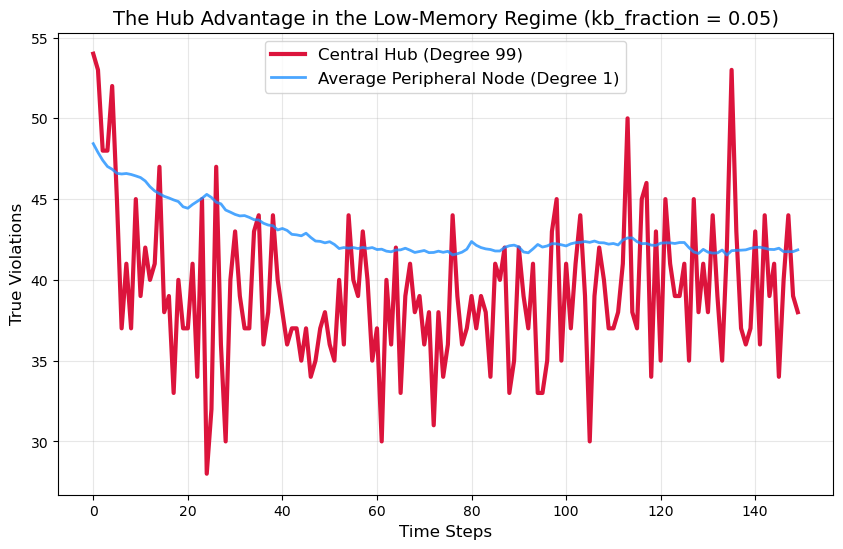

In [27]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a Star Graph (1 Hub, 99 Peripheral nodes)
N = 100
G_star = nx.star_graph(N - 1)

# Ensure math safety with self-loops
for i in range(N):
    G_star.add_edge(i, i)

# 2. Instantiate the model in the Low-Memory Regime
model_star = ProblemSolvingModel(
    setup_source="graph", 
    input_graph=G_star, 
    kb_fraction=0.05,  # Severely restricted memory! (5% of clauses)
    seed=101
)

# Note: We do NOT freeze the environment this time. 
# We want the full 100-variable, 100-clause problem to see the statistical advantage.

# 3. Data Collection Setup
steps = 150
hub_violations = []
periphery_violations = []

print("TEST 4: The Hub Advantage (Star Graph, Low Memory)")
print("Simulating...")

# 4. Run the simulation
for t in range(steps):
    model_star.step()
    
    # THE PROACTIVE REFLECTION PATCH
    # (Ensuring agents actively use the information they receive)
    for a in model_star.agents:
        for c in a.kb:
            a.local_update_around(c)
            
    # Collect Data
    # Node 0 is always the center of a networkx star_graph
    hub_v = model_star.agents[0].true_violations
    
    # Nodes 1 through N-1 are the periphery
    periph_v = np.mean([a.true_violations for a in model_star.agents[1:]])
    
    hub_violations.append(hub_v)
    periphery_violations.append(periph_v)

print("Simulation Complete. Plotting results...")

# 5. Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(hub_violations, label=f"Central Hub (Degree {N-1})", color="crimson", linewidth=3)
plt.plot(periphery_violations, label="Average Peripheral Node (Degree 1)", color="dodgerblue", alpha=0.8, linewidth=2)

# Formatting the plot
plt.title("The Hub Advantage in the Low-Memory Regime (kb_fraction = 0.05)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

Running 50 ensemble simulations...
Averaging complete. Plotting...


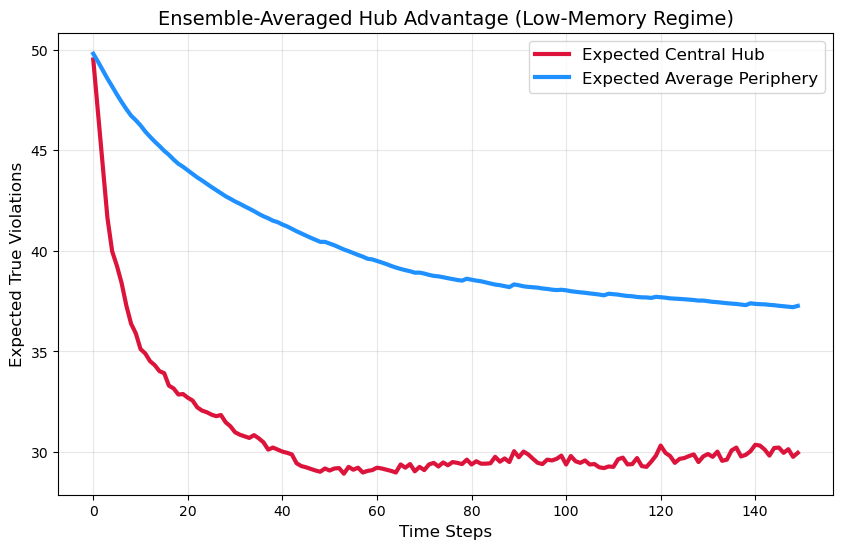

In [37]:
# --- ENSEMBLE AVERAGED STAR GRAPH ---
N = 100
steps = 150
num_runs = 50 # Average over 50 distinct runs to wash out the noise

# Matrices to store the trajectories for every run
all_hub_v = np.zeros((num_runs, steps))
all_periph_v = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations...")

for run in range(num_runs):
    G_star = nx.star_graph(N - 1)
    for i in range(N): G_star.add_edge(i, i)
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_star, 
        kb_fraction=0.75, 
        seed=run # Change the seed for every run!
    )
    
    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        all_hub_v[run, t] = model.agents[0].true_violations
        all_periph_v[run, t] = np.mean([a.true_violations for a in model.agents[1:]])

print("Averaging complete. Plotting...")

# Calculate the mean across all runs for each time step
mean_hub = np.mean(all_hub_v, axis=0)
mean_periph = np.mean(all_periph_v, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(mean_hub, label=f"Expected Central Hub", color="crimson", linewidth=3)
plt.plot(mean_periph, label="Expected Average Periphery", color="dodgerblue", linewidth=3)

plt.title("Ensemble-Averaged Hub Advantage (Low-Memory Regime)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. BA Network & Simulation Parameters
N = 100
m = 2          # Number of edges to attach from a new node to existing nodes
steps = 150
num_runs = 50  # 50 runs to match your excellent smoothing

# Matrices to store the trajectory sums (to average later)
hist_hubs = np.zeros((num_runs, steps))
hist_mid = np.zeros((num_runs, steps))
hist_periph = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations on Scale-Free Networks...")

# 2. Run the Ensemble
for run in range(num_runs):
    # Generate a new BA graph for every run
    G_BA = nx.barabasi_albert_graph(N, m, seed=run+5)
    for i in range(N): G_BA.add_edge(i, i) # Self-loops for math safety
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_BA, 
        kb_fraction=0.05, 
        seed=run
    )
    
    # Dynamically categorize nodes based on this specific run's degree distribution
    degrees = dict(G_BA.degree())
    # Note: Because of the self-loop, minimum degree is m+1 (which is 3)
    periph_nodes = [n for n, d in degrees.items() if d <= 4]
    hub_nodes = [n for n, d in degrees.items() if d >= 12]
    mid_nodes = [n for n, d in degrees.items() if 4 < d < 12]
    
    for t in range(steps):
        model.step()
        
        # Proactive Reflection Patch
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        # Record the mean violations for each class at this time step
        hist_hubs[run, t] = np.mean([model.agents[n].true_violations for n in hub_nodes]) if hub_nodes else 0
        hist_mid[run, t] = np.mean([model.agents[n].true_violations for n in mid_nodes]) if mid_nodes else 0
        hist_periph[run, t] = np.mean([model.agents[n].true_violations for n in periph_nodes]) if periph_nodes else 0

print("Simulation Complete. Plotting...")

# 3. Average across all runs
mean_hubs = np.mean(hist_hubs, axis=0)
mean_mid = np.mean(hist_mid, axis=0)
mean_periph = np.mean(hist_periph, axis=0)



Running 50 ensemble simulations on Scale-Free Networks...
Simulation Complete. Plotting...


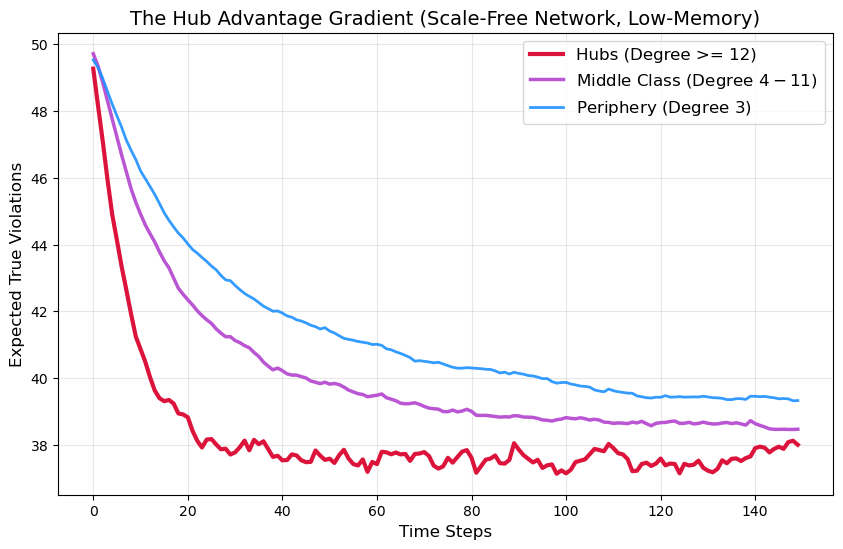

In [39]:
# 4. Plot the Hierarchy
plt.figure(figsize=(10, 6))

plt.plot(mean_hubs, label="Hubs (Degree >= 12)", color="crimson", linewidth=3)
plt.plot(mean_mid, label="Middle Class (Degree $4 - 11$)", color="mediumorchid", linewidth=2.5)
plt.plot(mean_periph, label="Periphery (Degree $3$)", color="dodgerblue", linewidth=2, alpha=0.9)

plt.title("The Hub Advantage Gradient (Scale-Free Network, Low-Memory)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. BA Network & Simulation Parameters
N = 100
m = 2          # Number of edges to attach from a new node to existing nodes
steps = 150
num_runs = 50  # 50 runs to match your excellent smoothing

# Matrices to store the trajectory sums (to average later)
hist_hubs = np.zeros((num_runs, steps))
hist_mid = np.zeros((num_runs, steps))
hist_periph = np.zeros((num_runs, steps))

print(f"Running {num_runs} ensemble simulations on Scale-Free Networks...")

# 2. Run the Ensemble
for run in range(num_runs):
    # Generate a new BA graph for every run
    G_BA = nx.barabasi_albert_graph(N, m, seed=run+5)
    for i in range(N): G_BA.add_edge(i, i) # Self-loops for math safety
        
    model = ProblemSolvingModel(
        setup_source="graph", 
        input_graph=G_BA, 
        kb_fraction=0.75, 
        seed=run
    )
    
    # Dynamically categorize nodes based on this specific run's degree distribution
    degrees = dict(G_BA.degree())
    # Note: Because of the self-loop, minimum degree is m+1 (which is 3)
    periph_nodes = [n for n, d in degrees.items() if d <= 4]
    hub_nodes = [n for n, d in degrees.items() if d >= 12]
    mid_nodes = [n for n, d in degrees.items() if 4 < d < 12]
    
    for t in range(steps):
        model.step()
        
        # Proactive Reflection Patch
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
                
        # Record the mean violations for each class at this time step
        hist_hubs[run, t] = np.mean([model.agents[n].true_violations for n in hub_nodes]) if hub_nodes else 0
        hist_mid[run, t] = np.mean([model.agents[n].true_violations for n in mid_nodes]) if mid_nodes else 0
        hist_periph[run, t] = np.mean([model.agents[n].true_violations for n in periph_nodes]) if periph_nodes else 0

print("Simulation Complete. Plotting...")

# 3. Average across all runs
mean_hubs = np.mean(hist_hubs, axis=0)
mean_mid = np.mean(hist_mid, axis=0)
mean_periph = np.mean(hist_periph, axis=0)



Running 50 ensemble simulations on Scale-Free Networks...
Simulation Complete. Plotting...


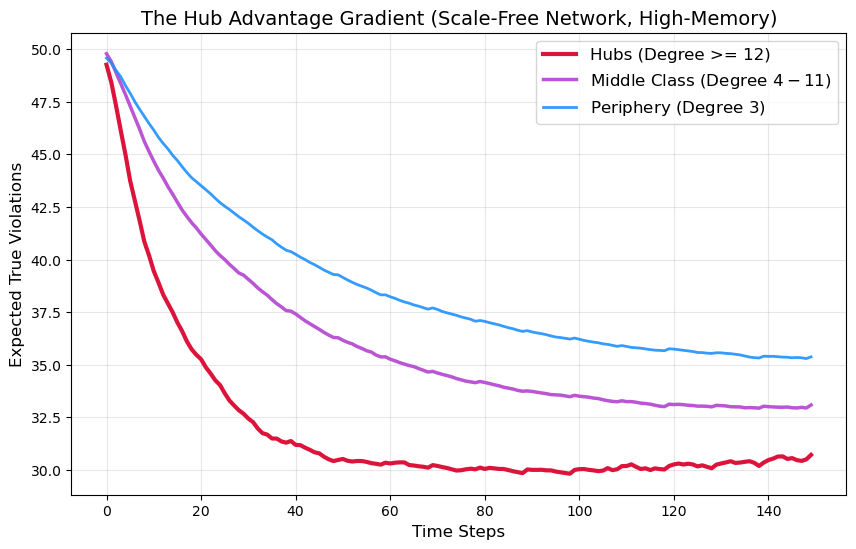

In [41]:
# 4. Plot the Hierarchy
plt.figure(figsize=(10, 6))

plt.plot(mean_hubs, label="Hubs (Degree >= 12)", color="crimson", linewidth=3)
plt.plot(mean_mid, label="Middle Class (Degree $4 - 11$)", color="mediumorchid", linewidth=2.5)
plt.plot(mean_periph, label="Periphery (Degree $3$)", color="dodgerblue", linewidth=2, alpha=0.9)

plt.title("The Hub Advantage Gradient (Scale-Free Network, High-Memory)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Expected True Violations", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()